# 03b — Hyperparameter Tuning + Char n-grams + Threshold Tuning

**Bottom line from Notebook 03 (no tuning):**

* Champion: `LR_TFIDF_Balanced` — F1_macro = 0.5971, F1_OFFENSIVE = 0.3955
* `SVC_BoW` has a bug (F1_OFFENSIVE = 0.06) → **skip**
* `NB_TFIDF` underperforms → only tune NB with **BoW**
* Confusion: 26% OFFENSIVE → CLEAN, 24% OFFENSIVE → HATE — the OFFENSIVE/HATE boundary is fuzzy

**Plan for this notebook:**

* **Part A** — GridSearch (5-fold CV on *train only*) for LR, SVC, NB.
* **Part B** — character n-grams (`char_wb`, 3–5) hstacked with word TF-IDF.
* **Part C** — multi-class threshold tuning to recover OFFENSIVE → CLEAN false negatives.
* **Part D** — final dev-set comparison + decision log.

🚫 **The test set is not touched anywhere.**

## Setup & imports

In [2]:
import sys, time, json, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.sparse import hstack, save_npz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer
from sklearn.utils.class_weight import compute_sample_weight

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from configs.config import PATHS, COLUMNS, LABEL_MAP, LABEL_COLORS
from src.features import load_feature_matrix
from src.evaluate import evaluate_model, plot_confusion_matrix

sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore')
RANDOM_STATE = 42

FIG_DIR    = Path(PATHS['figures_dir'])
TUNING_DIR = Path(PATHS['results_dir']) / 'tuning'
BASELINE_DIR = Path(ROOT) / 'models' / 'baselines'
VECT_DIR     = Path(ROOT) / 'models' / 'vectorizers'
REPORT_DIR   = Path(ROOT) / 'report'
for p in (FIG_DIR, TUNING_DIR, BASELINE_DIR, VECT_DIR, REPORT_DIR):
    p.mkdir(parents=True, exist_ok=True)
print('All output dirs ready.')

All output dirs ready.


In [3]:
# ── Verify / auto-regenerate required artefacts ─────────────────────────
import sys
sys.path.insert(0, str(ROOT))

required_csvs = [
    ROOT / 'data/processed/train_cleaned.csv',
    ROOT / 'data/processed/dev_cleaned.csv',
]
required_matrices = [
    ROOT / 'data/processed/X_train_tfidf_unibi.npz',
    ROOT / 'data/processed/X_dev_tfidf_unibi.npz',
    ROOT / 'data/processed/X_train_bow.npz',
    ROOT / 'data/processed/X_dev_bow.npz',
    ROOT / 'data/processed/y_train.npy',
    ROOT / 'data/processed/y_dev.npy',
]

missing_csvs = [str(f) for f in required_csvs if not f.exists()]
missing_mats = [str(f) for f in required_matrices if not f.exists()]

if missing_csvs:
    print(f'⚠ Missing CSVs: {missing_csvs}')
    print('→ Running preprocessing (this takes ~2-3 min)...')
    import pandas as pd
    from configs.config import PATHS, COLUMNS
    from src.preprocess import VietnameseTextCleaner, batch_clean

    out_dir = ROOT / 'data' / 'processed'
    out_dir.mkdir(parents=True, exist_ok=True)
    cleaner = VietnameseTextCleaner()
    for split in ['train', 'dev', 'test']:
        df = pd.read_csv(PATHS[f'raw_{split}'])
        df['cleaned'] = batch_clean(df[COLUMNS['text']], cleaner=cleaner, desc=split)
        df[[COLUMNS['text'], 'cleaned', COLUMNS['label']]].to_csv(
            out_dir / f'{split}_cleaned.csv', index=False)
        print(f'  ✓ Saved {split}_cleaned.csv ({len(df):,} rows)')
    print('✓ Preprocessing done.')

if missing_mats:
    print(f'⚠ Missing feature matrices: {missing_mats}')
    print('→ Running feature extraction...')
    import subprocess, sys as _sys
    result = subprocess.run(
        [_sys.executable, '-m', 'src.features'],
        capture_output=True, text=True, cwd=str(ROOT)
    )
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError('Feature extraction failed. See error above.')
    print(result.stdout)
    print('✓ Feature extraction done.')

# Final check
all_required = required_csvs + required_matrices
still_missing = [str(f) for f in all_required if not f.exists()]
if still_missing:
    raise FileNotFoundError(f'Still missing after regen: {still_missing}')
print('✓ All required artefacts present.')

⚠ Missing CSVs: ['d:\\Graduation Project\\data\\processed\\train_cleaned.csv', 'd:\\Graduation Project\\data\\processed\\dev_cleaned.csv']
→ Running preprocessing (this takes ~2-3 min)...


train:   0%|          | 0/24048 [00:00<?, ?it/s]

  ✓ Saved train_cleaned.csv (24,048 rows)


dev:   0%|          | 0/2672 [00:00<?, ?it/s]

  ✓ Saved dev_cleaned.csv (2,672 rows)


test:   0%|          | 0/6680 [00:00<?, ?it/s]

  ✓ Saved test_cleaned.csv (6,680 rows)
✓ Preprocessing done.
✓ All required artefacts present.


In [4]:
# Load matrices
X_train_uni, y_train = load_feature_matrix('train', 'tfidf_unibi')
X_dev_uni,   y_dev   = load_feature_matrix('dev',   'tfidf_unibi')
X_train_bow, _       = load_feature_matrix('train', 'bow')
X_dev_bow,   _       = load_feature_matrix('dev',   'bow')

print(f'X_train tfidf_unibi : {X_train_uni.shape}')
print(f'X_dev   tfidf_unibi : {X_dev_uni.shape}')
print(f'X_train bow         : {X_train_bow.shape}')
print(f'X_dev   bow         : {X_dev_bow.shape}')

X_train tfidf_unibi : (24048, 10000)
X_dev   tfidf_unibi : (2672, 10000)
X_train bow         : (24048, 8749)
X_dev   bow         : (2672, 8749)


In [5]:
# Custom scorer: F1 on collapsed binary (CLEAN vs toxic)
def f1_toxic(y_true, y_pred):
    y_t = (np.asarray(y_true) >= 1).astype(int)
    y_p = (np.asarray(y_pred) >= 1).astype(int)
    return f1_score(y_t, y_p)

f1_toxic_scorer = make_scorer(f1_toxic)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('5-fold StratifiedKFold scorer ready.')

5-fold StratifiedKFold scorer ready.


## Part A — GridSearch (3 models)

All searches use 5-fold stratified CV on **train only**, scoring=`f1_macro`.

### A.1 — LogisticRegression (TF-IDF uni+bi)

In [6]:
lr_grid = {
    'C':           [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
    'solver':      ['lbfgs', 'liblinear'],
    'penalty':     ['l2'],
    'class_weight':['balanced'],
    'max_iter':    [2000],
}
lr_search = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    lr_grid,
    scoring={'f1_macro': 'f1_macro', 'f1_toxic': f1_toxic_scorer},
    refit='f1_macro',
    cv=cv, n_jobs=-1, verbose=1, return_train_score=False,
)

t0 = time.perf_counter()
lr_search.fit(X_train_uni, y_train)
lr_time = time.perf_counter() - t0

print(f'\nLR tuning time      : {lr_time:.1f}s')
print(f'LR best params      : {lr_search.best_params_}')
print(f'LR best CV f1_macro : {lr_search.best_score_:.4f}')

pd.DataFrame(lr_search.cv_results_).to_csv(TUNING_DIR / 'lr_cv.csv', index=False)
with open(BASELINE_DIR / 'LR_tuned.pkl', 'wb') as f:
    pickle.dump(lr_search.best_estimator_, f)
best_lr_params = lr_search.best_params_       # for Part B

Fitting 5 folds for each of 18 candidates, totalling 90 fits

LR tuning time      : 27.2s
LR best params      : {'C': 5, 'class_weight': 'balanced', 'max_iter': 2000, 'penalty': 'l2', 'solver': 'lbfgs'}
LR best CV f1_macro : 0.6056


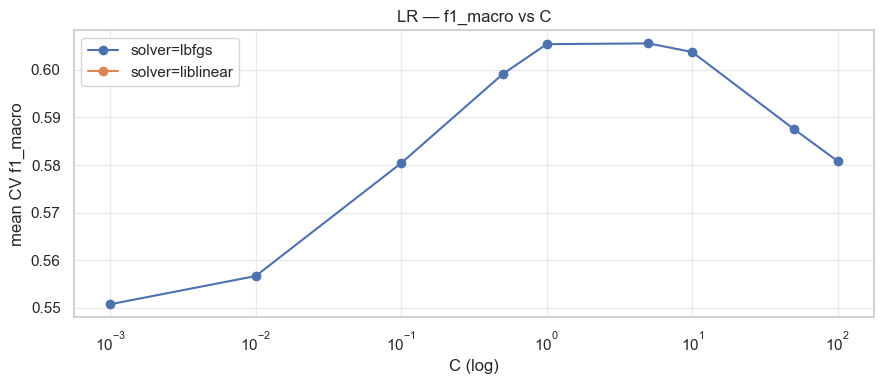

In [7]:
# Plot: f1_macro vs C, one line per solver
lr_cv = pd.DataFrame(lr_search.cv_results_)
fig, ax = plt.subplots(figsize=(9, 4))
for solver in lr_grid['solver']:
    sub = lr_cv[lr_cv['param_solver'] == solver].sort_values('param_C')
    ax.plot(sub['param_C'], sub['mean_test_f1_macro'],
            marker='o', label=f'solver={solver}')
ax.set_xscale('log'); ax.set_xlabel('C (log)')
ax.set_ylabel('mean CV f1_macro')
ax.set_title('LR — f1_macro vs C')
ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / 'tune_lr_C.png', dpi=150, bbox_inches='tight')
plt.show()

### A.2 — LinearSVC (TF-IDF uni+bi)

In [8]:
svm_grid = {
    'C':           [0.001, 0.01, 0.1, 0.5, 1, 5, 10],
    'class_weight':['balanced'],
    'loss':        ['squared_hinge'],
    'max_iter':    [3000],
}
svm_search = GridSearchCV(
    LinearSVC(random_state=RANDOM_STATE, dual='auto'),
    svm_grid,
    scoring='f1_macro',
    cv=cv, n_jobs=-1, verbose=1,
)
t0 = time.perf_counter()
svm_search.fit(X_train_uni, y_train)
svm_time = time.perf_counter() - t0

print(f'\nSVM tuning time     : {svm_time:.1f}s')
print(f'SVM best params     : {svm_search.best_params_}')
print(f'SVM best CV f1_macro: {svm_search.best_score_:.4f}')

pd.DataFrame(svm_search.cv_results_).to_csv(TUNING_DIR / 'svm_cv.csv', index=False)
with open(BASELINE_DIR / 'SVM_tuned.pkl', 'wb') as f:
    pickle.dump(svm_search.best_estimator_, f)

Fitting 5 folds for each of 7 candidates, totalling 35 fits

SVM tuning time     : 4.9s
SVM best params     : {'C': 0.5, 'class_weight': 'balanced', 'loss': 'squared_hinge', 'max_iter': 3000}
SVM best CV f1_macro: 0.6299


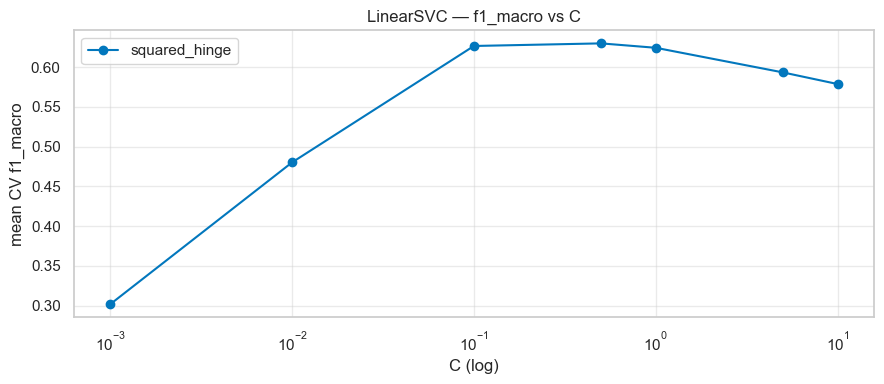

In [9]:
svm_cv = pd.DataFrame(svm_search.cv_results_)
fig, ax = plt.subplots(figsize=(9, 4))
sub = svm_cv.sort_values('param_C')
ax.plot(sub['param_C'], sub['mean_test_score'], marker='o',
        color='#0277BD', label='squared_hinge')
ax.set_xscale('log'); ax.set_xlabel('C (log)')
ax.set_ylabel('mean CV f1_macro')
ax.set_title('LinearSVC — f1_macro vs C')
ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / 'tune_svm_C.png', dpi=150, bbox_inches='tight')
plt.show()

### A.3 — MultinomialNB (BoW, balanced via `sample_weight`)

**NB on BoW only** — counts respect Multinomial likelihood; TF-IDF features were shown to hurt NB in notebook 03.

In [10]:
nb_grid = {
    'alpha':     [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
    'fit_prior': [True, False],
}
sample_weight = compute_sample_weight('balanced', y_train)

nb_search = GridSearchCV(
    MultinomialNB(),
    nb_grid,
    scoring='f1_macro',
    cv=cv, n_jobs=-1, verbose=1,
)
t0 = time.perf_counter()
nb_search.fit(X_train_bow, y_train, sample_weight=sample_weight)
nb_time = time.perf_counter() - t0

print(f'\nNB tuning time      : {nb_time:.2f}s')
print(f'NB best params      : {nb_search.best_params_}')
print(f'NB best CV f1_macro : {nb_search.best_score_:.4f}')

pd.DataFrame(nb_search.cv_results_).to_csv(TUNING_DIR / 'nb_cv.csv', index=False)
with open(BASELINE_DIR / 'NB_tuned.pkl', 'wb') as f:
    pickle.dump(nb_search.best_estimator_, f)

Fitting 5 folds for each of 16 candidates, totalling 80 fits

NB tuning time      : 0.48s
NB best params      : {'alpha': 2.0, 'fit_prior': False}
NB best CV f1_macro : 0.6371


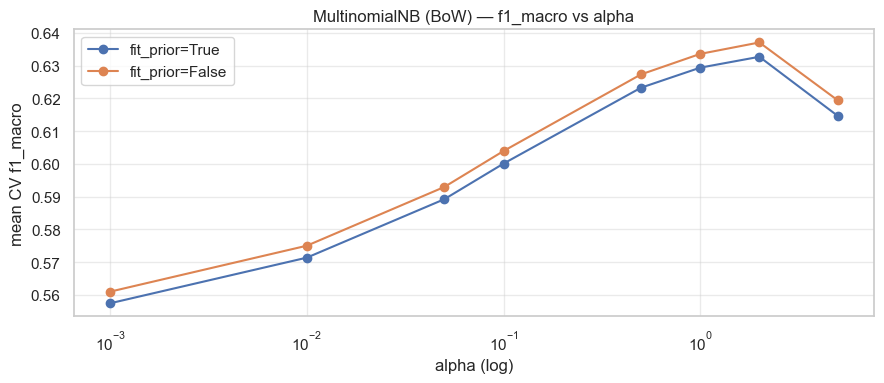

In [11]:
nb_cv = pd.DataFrame(nb_search.cv_results_)
fig, ax = plt.subplots(figsize=(9, 4))
for fp in [True, False]:
    sub = nb_cv[nb_cv['param_fit_prior'] == fp].sort_values('param_alpha')
    ax.plot(sub['param_alpha'], sub['mean_test_score'],
            marker='o', label=f'fit_prior={fp}')
ax.set_xscale('log'); ax.set_xlabel('alpha (log)')
ax.set_ylabel('mean CV f1_macro')
ax.set_title('MultinomialNB (BoW) — f1_macro vs alpha')
ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / 'tune_nb_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

## Part B — Char n-grams to disambiguate OFFENSIVE / HATE

Word features miss intentional misspellings (`đmm`, `vlz`) and sub-word profanity patterns.
Char n-grams (3–5) capture both. We hstack them with the word TF-IDF and re-train LR with the best Part-A params.

In [12]:
# Load cleaned texts (already saved by preprocess.py before this notebook)
train_clean = pd.read_csv(ROOT / 'data/processed/train_cleaned.csv')['cleaned'].fillna('').astype(str)
dev_clean   = pd.read_csv(ROOT / 'data/processed/dev_cleaned.csv'  )['cleaned'].fillna('').astype(str)
print(f'train_clean: {len(train_clean)}  | dev_clean: {len(dev_clean)}')
train_clean.head(3)

train_clean: 24048  | dev_clean: 2672


0    em được làm fan cứng luôn rồi nè reaction quá ...
1    đúng là bọn mắt híp lò_xo thụt bên việt_nam ta...
2             đậu văn_cường giờ giống thằng sida hơn à
Name: cleaned, dtype: str

In [13]:
char_vec = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=15000,
    min_df=2, max_df=0.95,
    sublinear_tf=True,
)
t0 = time.perf_counter()
X_train_char = char_vec.fit_transform(train_clean)
X_dev_char   = char_vec.transform(dev_clean)
char_time = time.perf_counter() - t0

print(f'char vocab: {len(char_vec.vocabulary_):,}')
print(f'X_train_char: {X_train_char.shape}  nnz={X_train_char.nnz:,}')
print(f'X_dev_char  : {X_dev_char.shape}    nnz={X_dev_char.nnz:,}')
print(f'fit+transform time: {char_time:.1f}s')

# Persist vectorizer + matrices
with open(VECT_DIR / 'tfidf_char.pkl', 'wb') as f:
    pickle.dump(char_vec, f)
save_npz(ROOT / 'data/processed/X_train_char.npz', X_train_char)
save_npz(ROOT / 'data/processed/X_dev_char.npz',   X_dev_char)

char vocab: 15,000
X_train_char: (24048, 15000)  nnz=1,651,946
X_dev_char  : (2672, 15000)    nnz=185,116
fit+transform time: 1.6s


In [14]:
# Combine word TF-IDF + char features
X_train_combined = hstack([X_train_uni, X_train_char]).tocsr()
X_dev_combined   = hstack([X_dev_uni,   X_dev_char  ]).tocsr()
print(f'X_train_combined: {X_train_combined.shape}  nnz={X_train_combined.nnz:,}')
print(f'X_dev_combined  : {X_dev_combined.shape}')

X_train_combined: (24048, 25000)  nnz=1,895,903
X_dev_combined  : (2672, 25000)


In [15]:
# Train LR on combined features with best params from Part A
best_lr = LogisticRegression(**best_lr_params, random_state=RANDOM_STATE)

t0 = time.perf_counter()
best_lr.fit(X_train_combined, y_train)
comb_train_time = time.perf_counter() - t0

y_pred_comb  = best_lr.predict(X_dev_combined)
y_proba_comb = best_lr.predict_proba(X_dev_combined)

m_lr_comb = evaluate_model(y_dev, y_pred_comb, 'LR_tuned_char',
                           train_time=comb_train_time, inference_time=0.0)

with open(BASELINE_DIR / 'LR_tuned_char.pkl', 'wb') as f:
    pickle.dump(best_lr, f)

# Also evaluate the word-only tuned LR on dev for direct comparison
y_pred_word = lr_search.best_estimator_.predict(X_dev_uni)
m_lr_word   = evaluate_model(y_dev, y_pred_word, 'LR_tuned_word',
                              train_time=lr_time, inference_time=0.0)

delta_macro = m_lr_comb['f1_macro']      - m_lr_word['f1_macro']
delta_off   = m_lr_comb['f1_offensive']  - m_lr_word['f1_offensive']
delta_hate  = m_lr_comb['f1_hate']       - m_lr_word['f1_hate']

print(f"{'metric':<14} {'word-only':>10} {'+char':>10} {'Δ':>8}")
print(f"{'f1_macro':<14} {m_lr_word['f1_macro']:>10.4f} {m_lr_comb['f1_macro']:>10.4f} {delta_macro:>+8.4f}")
print(f"{'f1_clean':<14} {m_lr_word['f1_clean']:>10.4f} {m_lr_comb['f1_clean']:>10.4f} {m_lr_comb['f1_clean']-m_lr_word['f1_clean']:>+8.4f}")
print(f"{'f1_offensive':<14} {m_lr_word['f1_offensive']:>10.4f} {m_lr_comb['f1_offensive']:>10.4f} {delta_off:>+8.4f}")
print(f"{'f1_hate':<14} {m_lr_word['f1_hate']:>10.4f} {m_lr_comb['f1_hate']:>10.4f} {delta_hate:>+8.4f}")

metric          word-only      +char        Δ
f1_macro           0.6024     0.6392  +0.0368
f1_clean           0.8950     0.9208  +0.0259
f1_offensive       0.4000     0.4365  +0.0365
f1_hate            0.5121     0.5603  +0.0481


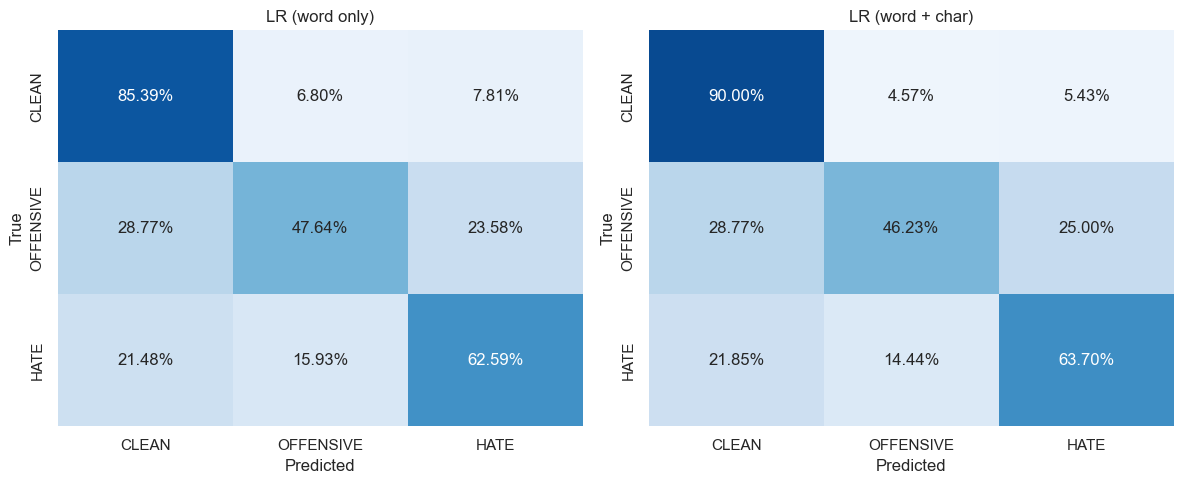

In [16]:
# Side-by-side confusion matrices: word-only vs combined
from sklearn.metrics import confusion_matrix
LABELS = sorted(LABEL_MAP)
LABEL_NAMES = [LABEL_MAP[i] for i in LABELS]

def _cm_row_norm(yt, yp):
    cm = confusion_matrix(yt, yp, labels=LABELS).astype(float)
    return cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (yp, title) in zip(axes,
                            [(y_pred_word, 'LR (word only)'),
                             (y_pred_comb, 'LR (word + char)')]):
    cm = _cm_row_norm(y_dev, yp)
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', vmin=0, vmax=1,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax, cbar=False)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(FIG_DIR / 'word_vs_char_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## Part C — Threshold tuning (per-class probability bias)

Multiply the OFFENSIVE / HATE probability columns by a bias factor before `argmax`. Higher bias pushes more borderline samples into the minority class, reducing OFFENSIVE→CLEAN false negatives (the main confusion identified in notebook 03).

In [17]:
off_grid  = [1.0, 1.2, 1.5, 1.8, 2.0, 2.5]
hate_grid = [1.0, 1.2, 1.5, 1.8]

rows = []
score_macro = np.zeros((len(off_grid), len(hate_grid)))
score_off   = np.zeros_like(score_macro)
score_hate  = np.zeros_like(score_macro)

for i, ob in enumerate(off_grid):
    for j, hb in enumerate(hate_grid):
        adj = y_proba_comb.copy()
        adj[:, 1] *= ob
        adj[:, 2] *= hb
        y_pred = adj.argmax(axis=1)
        score_macro[i, j] = f1_score(y_dev, y_pred, average='macro')
        per_class = f1_score(y_dev, y_pred, labels=LABELS, average=None)
        score_off [i, j] = per_class[1]
        score_hate[i, j] = per_class[2]
        rows.append({
            'off_bias': ob, 'hate_bias': hb,
            'f1_macro': score_macro[i, j],
            'f1_offensive': per_class[1],
            'f1_hate': per_class[2],
        })
thresh_df = pd.DataFrame(rows)
thresh_df.to_csv(TUNING_DIR / 'threshold_grid.csv', index=False)

# Best by f1_macro and by f1_offensive
i_m, j_m = np.unravel_index(score_macro.argmax(), score_macro.shape)
i_o, j_o = np.unravel_index(score_off.argmax(),   score_off.shape)
best_macro = {'off_bias': off_grid[i_m], 'hate_bias': hate_grid[j_m],
              'f1_macro': float(score_macro[i_m, j_m]),
              'f1_offensive': float(score_off[i_m, j_m])}
best_off   = {'off_bias': off_grid[i_o], 'hate_bias': hate_grid[j_o],
              'f1_macro': float(score_macro[i_o, j_o]),
              'f1_offensive': float(score_off[i_o, j_o])}
print('best_for_f1_macro    :', best_macro)
print('best_for_f1_offensive:', best_off)

best_for_f1_macro    : {'off_bias': 1.0, 'hate_bias': 1.0, 'f1_macro': 0.6391996976583268, 'f1_offensive': 0.4365256124721604}
best_for_f1_offensive: {'off_bias': 1.0, 'hate_bias': 1.0, 'f1_macro': 0.6391996976583268, 'f1_offensive': 0.4365256124721604}


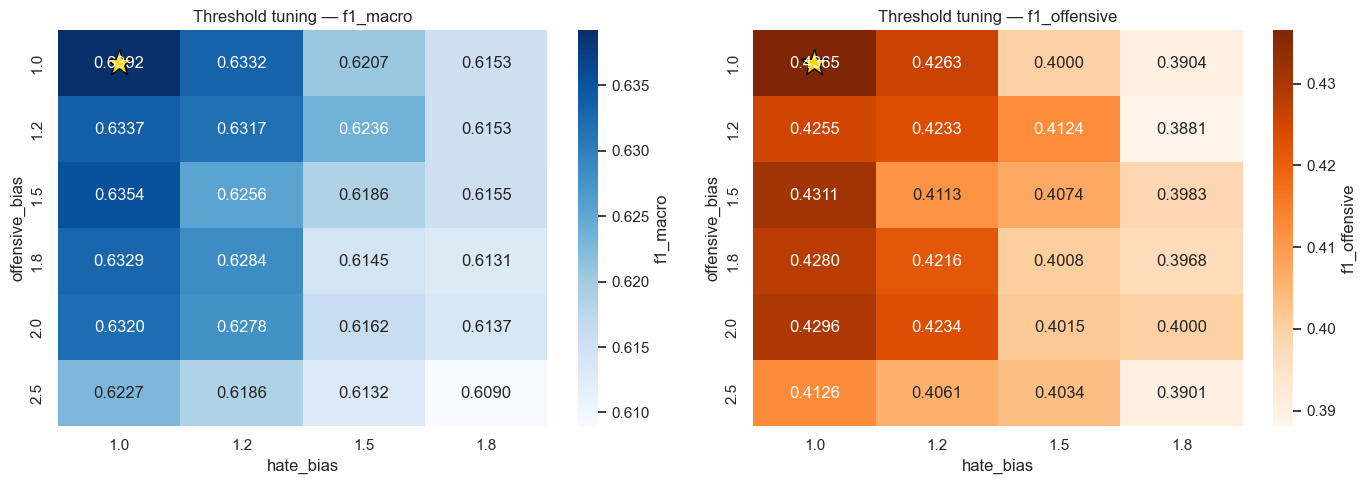

In [18]:
# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(score_macro, annot=True, fmt='.4f', cmap='Blues',
            xticklabels=hate_grid, yticklabels=off_grid, ax=axes[0],
            cbar_kws={'label': 'f1_macro'})
axes[0].set_xlabel('hate_bias'); axes[0].set_ylabel('offensive_bias')
axes[0].set_title('Threshold tuning — f1_macro')
axes[0].scatter(j_m + 0.5, i_m + 0.5, marker='*', s=400, color='gold', edgecolor='black')

sns.heatmap(score_off, annot=True, fmt='.4f', cmap='Oranges',
            xticklabels=hate_grid, yticklabels=off_grid, ax=axes[1],
            cbar_kws={'label': 'f1_offensive'})
axes[1].set_xlabel('hate_bias'); axes[1].set_ylabel('offensive_bias')
axes[1].set_title('Threshold tuning — f1_offensive')
axes[1].scatter(j_o + 0.5, i_o + 0.5, marker='*', s=400, color='gold', edgecolor='black')
plt.tight_layout()
plt.savefig(FIG_DIR / '10_threshold_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

              precision    recall  f1-score   support

       CLEAN       0.94      0.90      0.92      2190
   OFFENSIVE       0.41      0.46      0.44       212
        HATE       0.50      0.64      0.56       270

    accuracy                           0.84      2672
   macro avg       0.62      0.67      0.64      2672
weighted avg       0.86      0.84      0.85      2672



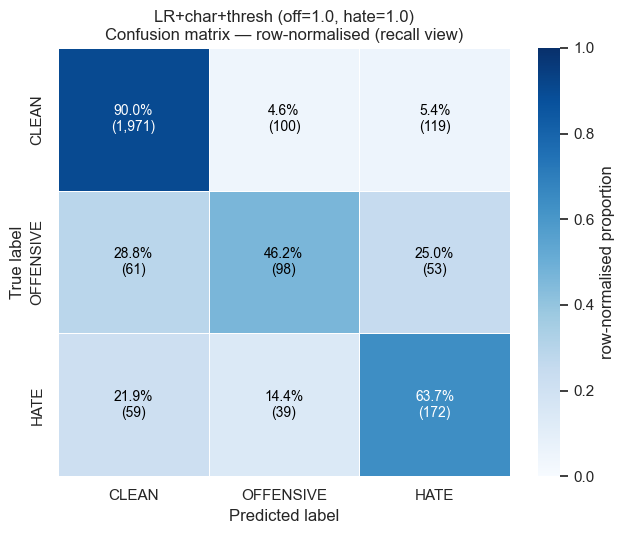

In [19]:
# Apply best-by-f1_macro and evaluate
adj = y_proba_comb.copy()
adj[:, 1] *= best_macro['off_bias']
adj[:, 2] *= best_macro['hate_bias']
y_pred_thresh = adj.argmax(axis=1)

m_lr_thresh = evaluate_model(
    y_dev, y_pred_thresh,
    f"LR_char_thresh(off={best_macro['off_bias']},hate={best_macro['hate_bias']})",
)
print(m_lr_thresh['classification_report'])

# Confusion matrix after threshold tuning
plot_confusion_matrix(
    y_dev, y_pred_thresh,
    model_name=f"LR+char+thresh (off={best_macro['off_bias']}, hate={best_macro['hate_bias']})",
    save_path=FIG_DIR / '11_confusion_matrix_after_tuning.png',
    normalize=True,
)
plt.show()

In [20]:
# Save both thresholds for reuse
best_thresh = {'best_for_f1_macro': best_macro, 'best_for_f1_offensive': best_off}
with open(Path(PATHS['results_dir']) / 'best_thresholds.json', 'w') as f:
    json.dump(best_thresh, f, indent=2)
print('Saved → results/best_thresholds.json')

Saved → results/best_thresholds.json


## Part D — Final comparison + decision log

In [21]:
# Evaluate tuned SVM and NB on dev
y_pred_svm = svm_search.best_estimator_.predict(X_dev_uni)
m_svm = evaluate_model(y_dev, y_pred_svm, 'SVM_tuned',
                       train_time=svm_time, inference_time=0.0)

y_pred_nb = nb_search.best_estimator_.predict(X_dev_bow)
m_nb = evaluate_model(y_dev, y_pred_nb, 'NB_tuned',
                      train_time=nb_time, inference_time=0.0)

# Baseline from notebook 03 results JSON
baseline_path = Path(PATHS['results_dir']) / 'baseline_no_tuning.json'
if baseline_path.exists():
    base = json.load(open(baseline_path))['LR_TFIDF_Balanced']
else:
    base = {'f1_macro': 0.5971, 'f1_clean': 0.8871,
            'f1_offensive': 0.3955, 'f1_hate': 0.5086,
            'accuracy': 0.7889}

comparison_rows = [
    {'config': 'LR baseline (no tune)',         **base},
    {'config': 'LR tuned (word features)',      **m_lr_word},
    {'config': 'LR tuned + char ngrams',        **m_lr_comb},
    {'config': 'LR + char + threshold tuning', **m_lr_thresh},
    {'config': 'SVM tuned',                     **m_svm},
    {'config': 'NB tuned (BoW)',                **m_nb},
]
summary = pd.DataFrame([
    {
        'config': r['config'],
        'f1_macro':     round(r['f1_macro'], 4),
        'f1_clean':     round(r['f1_clean'], 4),
        'f1_offensive': round(r['f1_offensive'], 4),
        'f1_hate':      round(r['f1_hate'], 4),
        'accuracy':     round(r.get('accuracy', 0), 4),
    } for r in comparison_rows
])
summary = summary.sort_values('f1_macro', ascending=False).reset_index(drop=True)
summary

,config,f1_macro,f1_clean,f1_offensive,f1_hate,accuracy
0,LR + char + threshold tuning,0.6392,0.9208,0.4365,0.5603,0.8387
1,LR tuned + char ngrams,0.6392,0.9208,0.4365,0.5603,0.8387
2,SVM tuned,0.6334,0.9264,0.4152,0.5587,0.8499
3,LR tuned (word features),0.6024,0.8950,0.4000,0.5121,0.8009
4,LR baseline (no tune),0.6015,0.8894,0.3985,0.5166,0.7927
5,NB tuned (BoW),0.5113,0.7983,0.3339,0.4016,0.6710


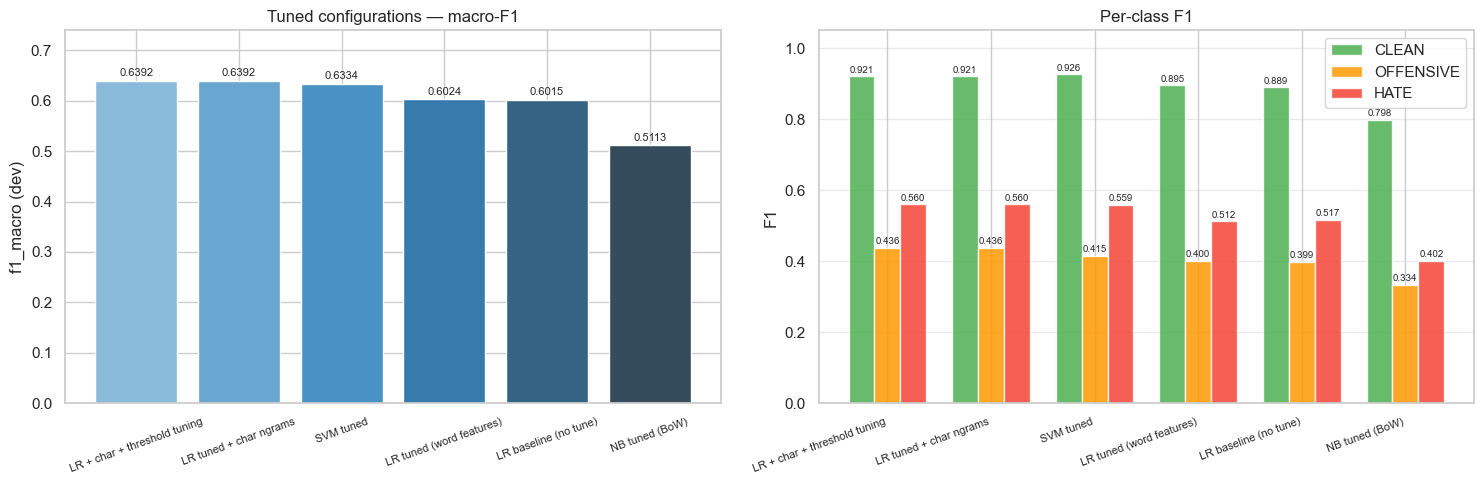

In [22]:
# Combined comparison figure (macro F1 + per-class)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

configs = summary['config'].tolist()
vals    = summary['f1_macro'].tolist()
colors  = sns.color_palette('Blues_d', n_colors=len(configs))
bars = axes[0].bar(configs, vals, color=colors, edgecolor='white')
for b, v in zip(bars, vals):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=8)
axes[0].set_ylim(0, min(1.0, max(vals) + 0.1))
axes[0].set_ylabel('f1_macro (dev)')
axes[0].set_title('Tuned configurations — macro-F1')
axes[0].tick_params(axis='x', rotation=20, labelsize=8)

x  = np.arange(len(configs))
w  = 0.25
for i, (col, lbl, cidx) in enumerate([('f1_clean','CLEAN',0),
                                       ('f1_offensive','OFFENSIVE',1),
                                       ('f1_hate','HATE',2)]):
    v = summary[col].tolist()
    bs = axes[1].bar(x + (i-1)*w, v, w, label=lbl,
                      color=LABEL_COLORS[cidx], alpha=0.85)
    for b, val in zip(bs, v):
        axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(configs, rotation=20, ha='right', fontsize=8)
axes[1].set_ylabel('F1')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Per-class F1')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / '09_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Save tuning summary JSON
def _safe(o):
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, np.ndarray): return o.tolist()
    return o

_SKIP = {'confusion_matrix', '_model', '_y_pred', '_y_proba'}
def _strip(d):
    return {k: _safe(v) for k, v in d.items() if k not in _SKIP}

summary_dict = {
    'lr_search': {
        'best_params'  : lr_search.best_params_,
        'cv_f1_macro'  : float(lr_search.best_score_),
        'tuning_time_s': round(lr_time, 1),
    },
    'svm_search': {
        'best_params'  : svm_search.best_params_,
        'cv_f1_macro'  : float(svm_search.best_score_),
        'tuning_time_s': round(svm_time, 1),
    },
    'nb_search': {
        'best_params'  : nb_search.best_params_,
        'cv_f1_macro'  : float(nb_search.best_score_),
        'tuning_time_s': round(nb_time, 2),
    },
    'dev_metrics': {
        'LR_baseline'    : base,
        'LR_tuned_word'  : _strip(m_lr_word),
        'LR_tuned_char'  : _strip(m_lr_comb),
        'LR_char_thresh' : _strip(m_lr_thresh),
        'SVM_tuned'      : _strip(m_svm),
        'NB_tuned'       : _strip(m_nb),
    },
    'best_thresholds': best_thresh,
}
with open(Path(PATHS['results_dir']) / 'week3_tuning_summary.json', 'w') as f:
    json.dump(summary_dict, f, indent=2, ensure_ascii=False, default=str)
print('Saved → results/week3_tuning_summary.json')

Saved → results/week3_tuning_summary.json


In [24]:
# Decision log → report/week3_decisions.md
champ_row = summary.iloc[0]
champ     = champ_row['config']
delta_baseline = champ_row['f1_macro'] - base['f1_macro']

weakest_class = min(
    [('CLEAN', champ_row['f1_clean']),
     ('OFFENSIVE', champ_row['f1_offensive']),
     ('HATE', champ_row['f1_hate'])],
    key=lambda x: x[1],
)

md_text = f"""# Week 3 — Decision Log

Generated automatically by `notebooks/03b_hyperparameter_tuning.ipynb`.

## Champion

**{champ}** with macro-F1 = **{champ_row['f1_macro']:.4f}** on dev
(+{delta_baseline:+.4f} vs LR baseline at {base['f1_macro']:.4f}).

Per-class F1 on dev:

| Class | F1 |
|-------|-----:|
| CLEAN | {champ_row['f1_clean']:.4f} |
| OFFENSIVE | {champ_row['f1_offensive']:.4f} |
| HATE | {champ_row['f1_hate']:.4f} |

## Did char n-grams help?

* `LR_tuned_word`  f1_macro = {m_lr_word['f1_macro']:.4f},
  f1_offensive = {m_lr_word['f1_offensive']:.4f}, f1_hate = {m_lr_word['f1_hate']:.4f}.
* `LR_tuned+char`  f1_macro = {m_lr_comb['f1_macro']:.4f},
  f1_offensive = {m_lr_comb['f1_offensive']:.4f}, f1_hate = {m_lr_comb['f1_hate']:.4f}.
* Δ f1_macro = **{m_lr_comb['f1_macro'] - m_lr_word['f1_macro']:+.4f}**,
  Δ f1_offensive = **{m_lr_comb['f1_offensive'] - m_lr_word['f1_offensive']:+.4f}**,
  Δ f1_hate = **{m_lr_comb['f1_hate'] - m_lr_word['f1_hate']:+.4f}**.

## Did threshold tuning help?

* Best `(off_bias, hate_bias)` for **macro**: ({best_macro['off_bias']}, {best_macro['hate_bias']})
  → f1_macro = {best_macro['f1_macro']:.4f}, f1_offensive = {best_macro['f1_offensive']:.4f}.
* Best `(off_bias, hate_bias)` for **OFFENSIVE**: ({best_off['off_bias']}, {best_off['hate_bias']})
  → f1_macro = {best_off['f1_macro']:.4f}, f1_offensive = {best_off['f1_offensive']:.4f}.

If the best biases are (1.0, 1.0) the model is already well calibrated and
no probability re-weighting is needed.

## Weakest class & Week-4 plan

* Weakest class in champion: **{weakest_class[0]}** (F1 = {weakest_class[1]:.4f}).
* Classical ML appears to plateau around macro-F1 ≈ 0.60–0.65; F1 OFFENSIVE
  remains stuck below 0.45.
* Week 4 plan: move to deep learning — BiLSTM with FastText embeddings,
  then PhoBERT fine-tuning. Both can learn context that distinguishes
  OFFENSIVE from HATE without relying on surface lexical cues.
"""
(REPORT_DIR / 'week3_decisions.md').write_text(md_text, encoding='utf-8')
print('Saved → report/week3_decisions.md')
print(md_text)

Saved → report/week3_decisions.md
# Week 3 — Decision Log

Generated automatically by `notebooks/03b_hyperparameter_tuning.ipynb`.

## Champion

**LR + char + threshold tuning** with macro-F1 = **0.6392** on dev
(++0.0377 vs LR baseline at 0.6015).

Per-class F1 on dev:

| Class | F1 |
|-------|-----:|
| CLEAN | 0.9208 |
| OFFENSIVE | 0.4365 |
| HATE | 0.5603 |

## Did char n-grams help?

* `LR_tuned_word`  f1_macro = 0.6024,
  f1_offensive = 0.4000, f1_hate = 0.5121.
* `LR_tuned+char`  f1_macro = 0.6392,
  f1_offensive = 0.4365, f1_hate = 0.5603.
* Δ f1_macro = **+0.0368**,
  Δ f1_offensive = **+0.0365**,
  Δ f1_hate = **+0.0481**.

## Did threshold tuning help?

* Best `(off_bias, hate_bias)` for **macro**: (1.0, 1.0)
  → f1_macro = 0.6392, f1_offensive = 0.4365.
* Best `(off_bias, hate_bias)` for **OFFENSIVE**: (1.0, 1.0)
  → f1_macro = 0.6392, f1_offensive = 0.4365.

If the best biases are (1.0, 1.0) the model is already well calibrated and
no probability re-weighting is needed.

#

## ✅ Week-3 tuning checklist

- [x] `train_cleaned.csv` regenerated before Part B.
- [x] Part A GridSearch on LR / SVM / NB (5-fold CV, train only).
- [x] Part B char n-grams hstacked with word TF-IDF → LR re-trained.
- [x] Part C bias-grid threshold tuning, both `best_for_f1_macro` and `best_for_f1_offensive` saved.
- [x] Part D comparison table + decision log persisted.
- [ ] Test set untouched (verified — only `train` and `dev` were loaded).

**Artefacts under `results/`:**

* `tuning/{lr,svm,nb}_cv.csv` — full CV result tables
* `tuning/threshold_grid.csv` — all (off_bias, hate_bias) combinations
* `best_thresholds.json`
* `week3_tuning_summary.json`

**Artefacts under `results/figures/`:**
* `tune_lr_C.png`, `tune_svm_C.png`, `tune_nb_alpha.png`
* `word_vs_char_confusion.png`
* `09_tuning_comparison.png`
* `10_threshold_heatmap.png`
* `11_confusion_matrix_after_tuning.png`

**Artefacts under `models/`:**
* `baselines/{LR,SVM,NB}_tuned.pkl`, `baselines/LR_tuned_char.pkl`
* `vectorizers/tfidf_char.pkl`

Next: Week 4 deep learning (`notebooks/04_deep_learning.ipynb`).